## **Exploratory Data Analysis (EDA)**

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# import dataset

df = pd.read_csv("sample.csv")
df = df.drop(columns = ["id"])
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


### 1. Basic Checks

In [5]:
df.shape

(58645, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  58645 non-null  int64  
 1   person_income               58645 non-null  int64  
 2   person_home_ownership       58645 non-null  object 
 3   person_emp_length           58645 non-null  float64
 4   loan_intent                 58645 non-null  object 
 5   loan_grade                  58645 non-null  object 
 6   loan_amnt                   58645 non-null  int64  
 7   loan_int_rate               58645 non-null  float64
 8   loan_percent_income         58645 non-null  float64
 9   cb_person_default_on_file   58645 non-null  object 
 10  cb_person_cred_hist_length  58645 non-null  int64  
 11  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 5.4+ MB


In [7]:
df.describe(include = "all")

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
count,58645.000000,5.864500e+04,58645,58645.000000,58645,58645,58645.000000,58645.000000,58645.000000,58645,58645.000000,58645.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,2,NaN,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,N,NaN,NaN
freq,NaN,NaN,30594,NaN,12271,20984,NaN,NaN,NaN,49943,NaN,NaN
mean,27.550857,6.404617e+04,NaN,4.701015,NaN,NaN,9217.556518,10.677874,0.159238,NaN,5.813556,0.142382
std,6.033216,3.793111e+04,NaN,3.959784,NaN,NaN,5563.807384,3.034697,0.091692,NaN,4.029196,0.349445
min,20.000000,4.200000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,NaN,2.000000,0.000000
25%,23.000000,4.200000e+04,NaN,2.000000,NaN,NaN,5000.000000,7.880000,0.090000,NaN,3.000000,0.000000
50%,26.000000,5.800000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.750000,0.140000,NaN,4.000000,0.000000
75%,30.000000,7.560000e+04,NaN,7.000000,NaN,NaN,12000.000000,12.990000,0.210000,NaN,8.000000,0.000000


In [8]:
# suspicious extreme values

# person_age = 123
df.nlargest(10, "person_age")

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
47336,123,36000,MORTGAGE,7.0,PERSONAL,B,6700,10.75,0.18,N,4,0
4962,84,108928,MORTGAGE,3.0,DEBTCONSOLIDATION,A,6000,7.51,0.06,N,25,0
6750,84,94800,MORTGAGE,2.0,PERSONAL,D,10000,14.09,0.11,N,22,0
15588,80,54000,RENT,27.0,PERSONAL,A,10000,6.62,0.19,N,25,1
21953,80,30000,RENT,7.0,MEDICAL,D,5000,14.96,0.17,N,24,1
16954,76,30000,RENT,2.0,HOMEIMPROVEMENT,D,6500,16.77,0.21,N,24,1
6425,73,32004,MORTGAGE,3.0,PERSONAL,B,7500,10.65,0.24,N,23,0
24266,73,40000,RENT,0.0,MEDICAL,B,1800,11.36,0.04,N,21,0
25499,73,42000,RENT,7.0,PERSONAL,D,13750,14.96,0.32,N,24,1
5597,70,21600,RENT,0.0,MEDICAL,A,6000,6.99,0.28,N,24,0


In [9]:
# person_emp_length = 123
df.nlargest(10, "person_emp_length")

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
41079,28,60350,MORTGAGE,123.0,MEDICAL,D,25000,15.95,0.35,Y,6,1
49252,21,192000,MORTGAGE,123.0,VENTURE,B,20000,11.49,0.10,N,2,0
9997,58,48000,RENT,41.0,PERSONAL,D,7500,13.55,0.17,Y,24,0
26125,43,56000,RENT,41.0,HOMEIMPROVEMENT,B,2000,10.99,0.04,N,14,0
50559,56,70000,RENT,39.0,MEDICAL,B,8000,11.36,0.11,N,17,0
24214,43,50000,RENT,35.0,DEBTCONSOLIDATION,A,9000,5.42,0.18,N,16,0
29271,47,53913,MORTGAGE,31.0,HOMEIMPROVEMENT,B,7000,10.71,0.13,N,13,1
39112,46,84000,MORTGAGE,31.0,HOMEIMPROVEMENT,D,20000,17.49,0.24,N,8,0
48287,48,70000,MORTGAGE,31.0,HOMEIMPROVEMENT,A,9000,8.94,0.13,N,8,0
52038,38,42000,MORTGAGE,31.0,VENTURE,B,11000,11.49,0.26,N,14,0


In [10]:
# person_income = 1900000
df.nlargest(10, "person_income")

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
17387,22,1900000,MORTGAGE,6.0,EDUCATION,D,1500,15.62,0.00,Y,3,0
12404,25,1839784,RENT,0.0,VENTURE,A,8000,8.00,0.04,N,3,0
37591,29,1824000,MORTGAGE,8.0,DEBTCONSOLIDATION,C,6000,13.99,0.03,N,6,0
2093,32,1200000,RENT,2.0,PERSONAL,A,10000,7.51,0.01,N,9,0
19060,32,1200000,MORTGAGE,16.0,DEBTCONSOLIDATION,A,16000,6.92,0.13,N,5,0
11422,29,948000,OWN,11.0,PERSONAL,B,4000,11.83,0.04,N,5,0
34752,27,928000,MORTGAGE,8.0,VENTURE,C,2850,13.92,0.01,N,7,0
18465,32,900000,RENT,13.0,PERSONAL,B,25000,11.49,0.03,N,5,0
31446,26,900000,MORTGAGE,3.0,VENTURE,B,6000,9.91,0.01,N,3,0
37902,35,900000,MORTGAGE,18.0,PERSONAL,B,4500,10.65,0.01,N,6,0


=> person_age contains unrealistic values (123 years old).

=> person_emp_length contains unrealistic values (123 years).

=> person_income is highly right-skewed with several extremely high-income observations. These values may represent genuine high earners rather than data errors.

In [12]:
# drop unreasonable values in age and employment length

df = df[(df["person_age"] <= 100) & (df["person_emp_length"] <= 100)]

In [13]:
# missing values

df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [14]:
# duplicated records

df.duplicated().sum()

0

### 2. Dependent Variable

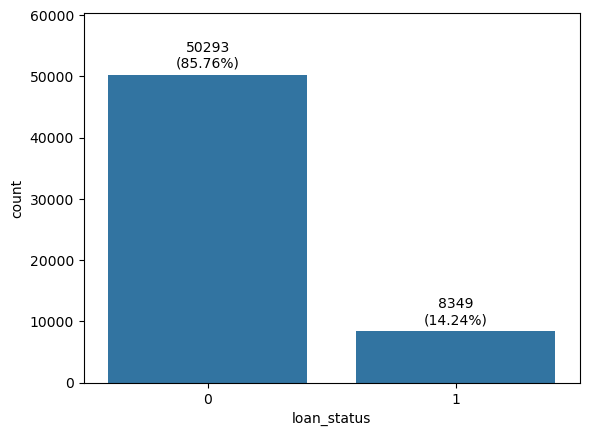

In [16]:
plot = sns.countplot(x = "loan_status", data = df)
total = len(df)

labels = [f"{int(bar.get_height())}\n({100 * bar.get_height() / total:.2f}%)" for bar in plot.containers[0]]
plot.bar_label(plot.containers[0], labels = labels, padding = 3)

plt.margins(y = 0.2)
plt.show()

=> The dataset is imbalanced, with approximately 14.24% default loans and 85.76% non-default loans.

Do not rely on Accuracy alone. Evaluate performance using Precision, Recall, F1-score, or ROC-AUC.
Handle class imbalance using SMOTE or Class Weights.

### 3. Independent Variables

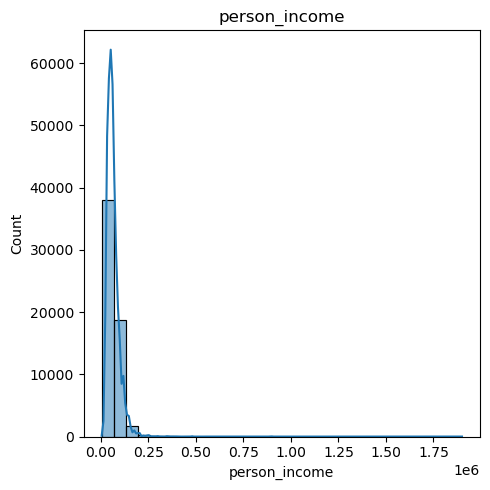

In [19]:
# person_income

plt.figure(figsize = (5, 5))
sns.histplot(data = df, x = "person_income", kde = True, bins = 30)
plt.title("person_income")
plt.tight_layout()
plt.show()

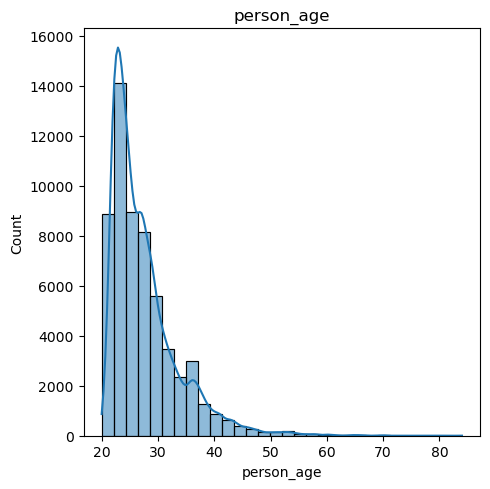

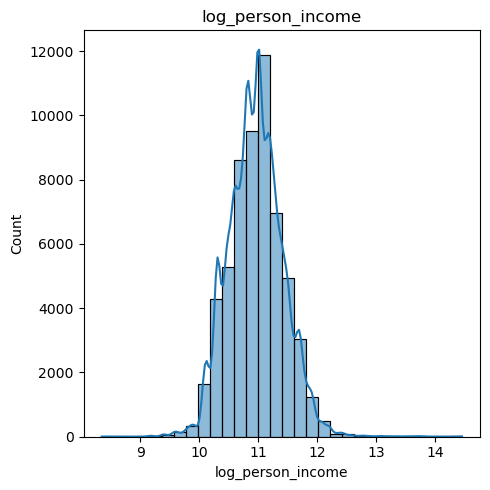

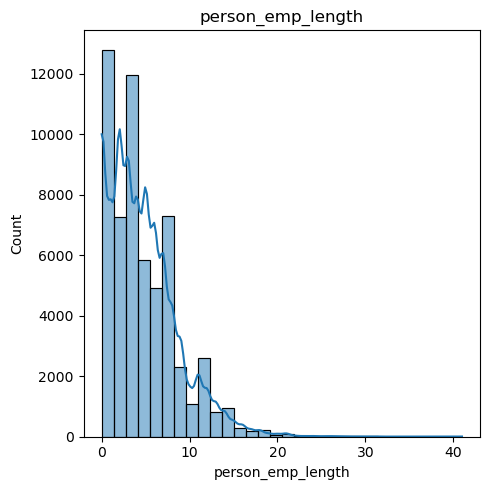

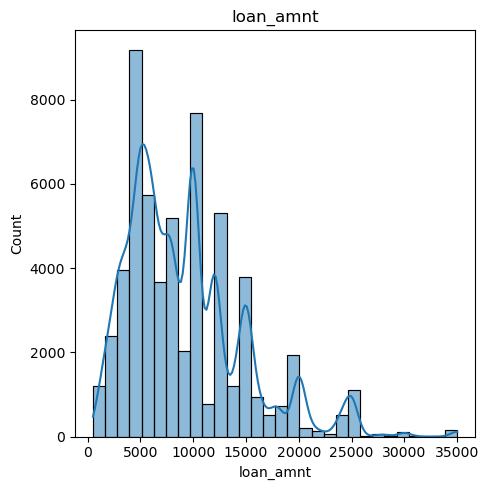

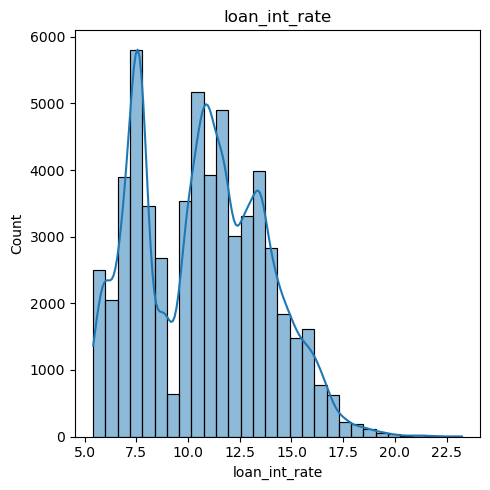

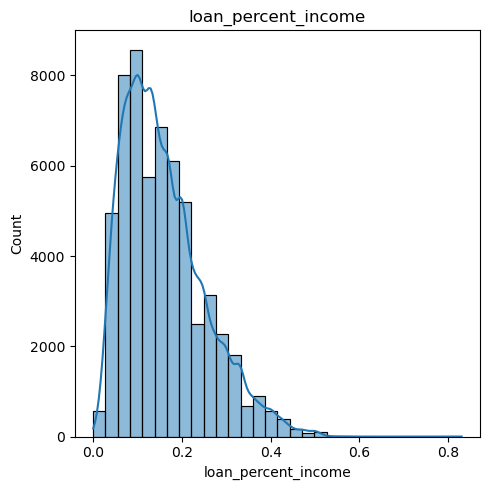

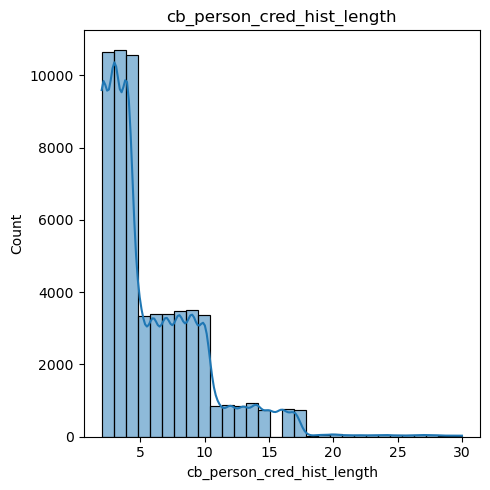

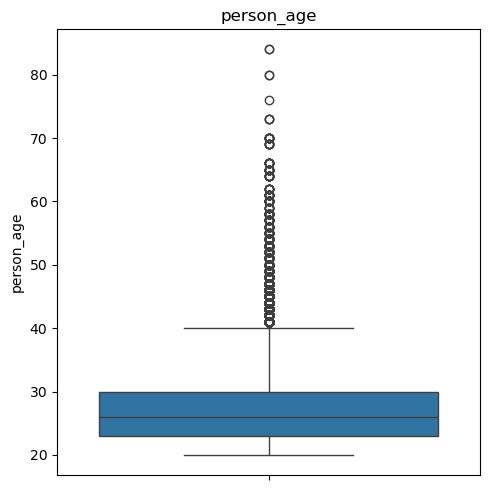

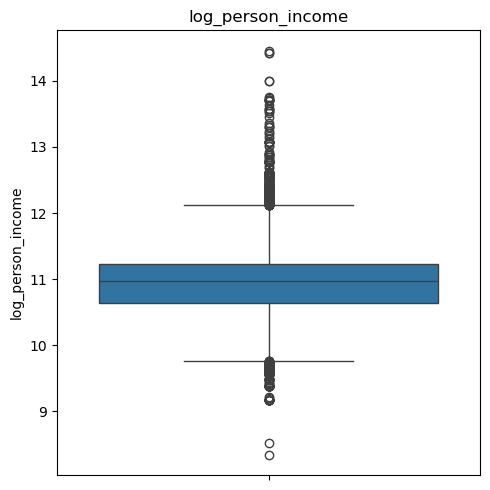

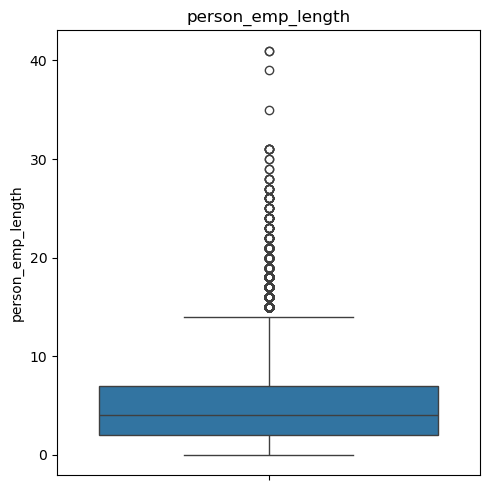

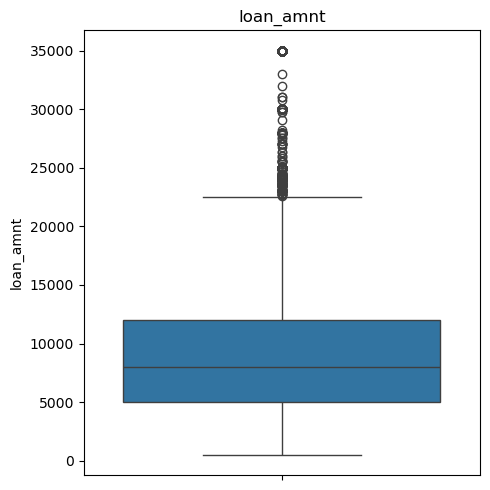

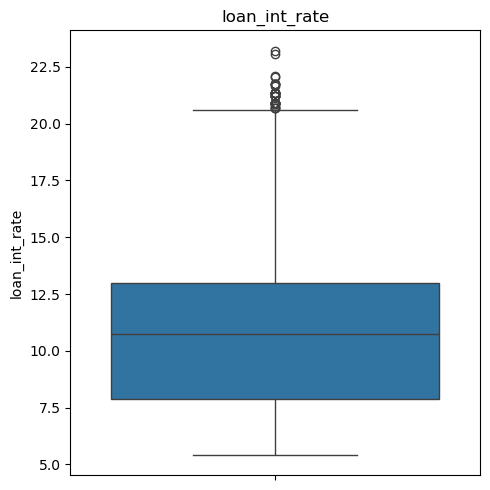

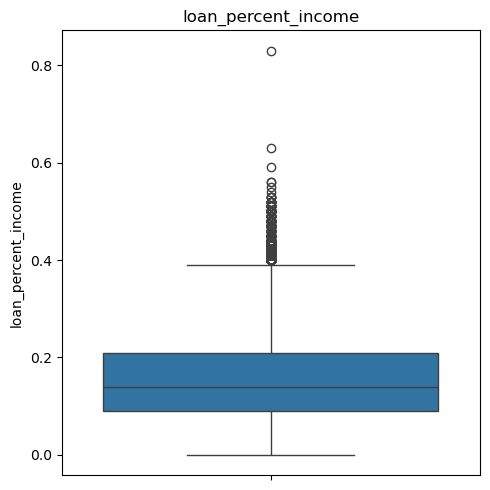

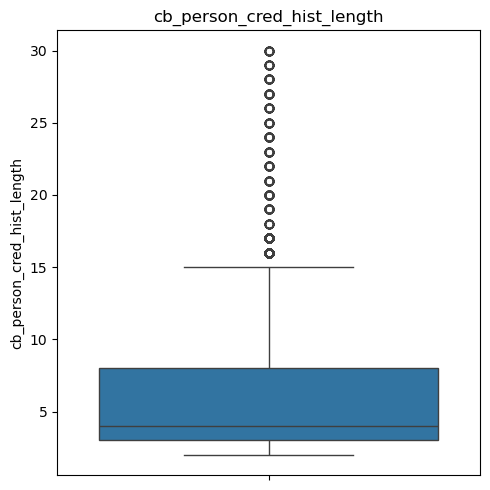

In [20]:
# log transformation
df["log_person_income"] = np.log1p(df["person_income"])

numerical_cols = ["person_age", "log_person_income", "person_emp_length", "loan_amnt", "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]

# histplot

for col in numerical_cols:
    plt.figure(figsize = (5, 5))
    sns.histplot(data = df, x = col, kde = True, bins = 30)
    plt.title(col)
    plt.tight_layout()
    plt.show()

# boxplot

for col in numerical_cols:
    plt.figure(figsize = (5, 5))
    sns.boxplot(data = df, y = col)
    plt.title(col)
    plt.tight_layout()
    plt.show()

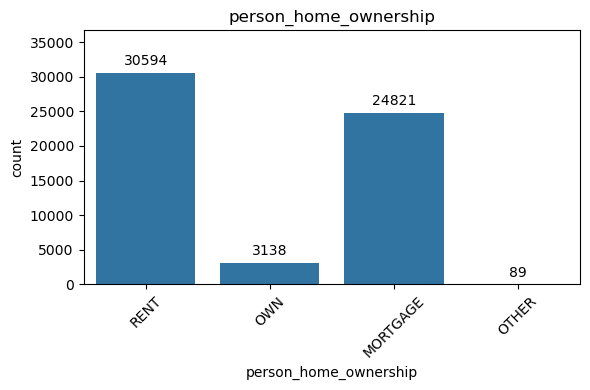

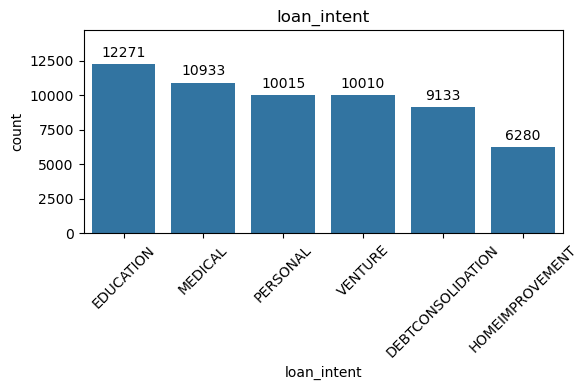

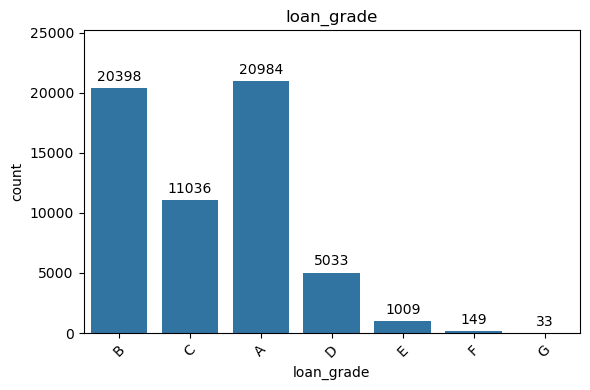

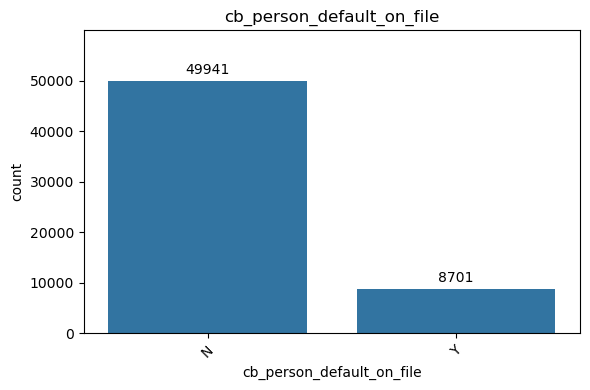

In [21]:
categorical_cols = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]

# countplot

for col in categorical_cols:
    plt.figure(figsize = (6, 4))
    ax = sns.countplot(data = df, x = col)
    ax.bar_label(ax.containers[0], padding = 3)
    plt.xticks(rotation = 45)
    plt.margins(y = 0.2)
    plt.title(col)
    plt.tight_layout()
    plt.show()

### 4. Relationship with Loan Status

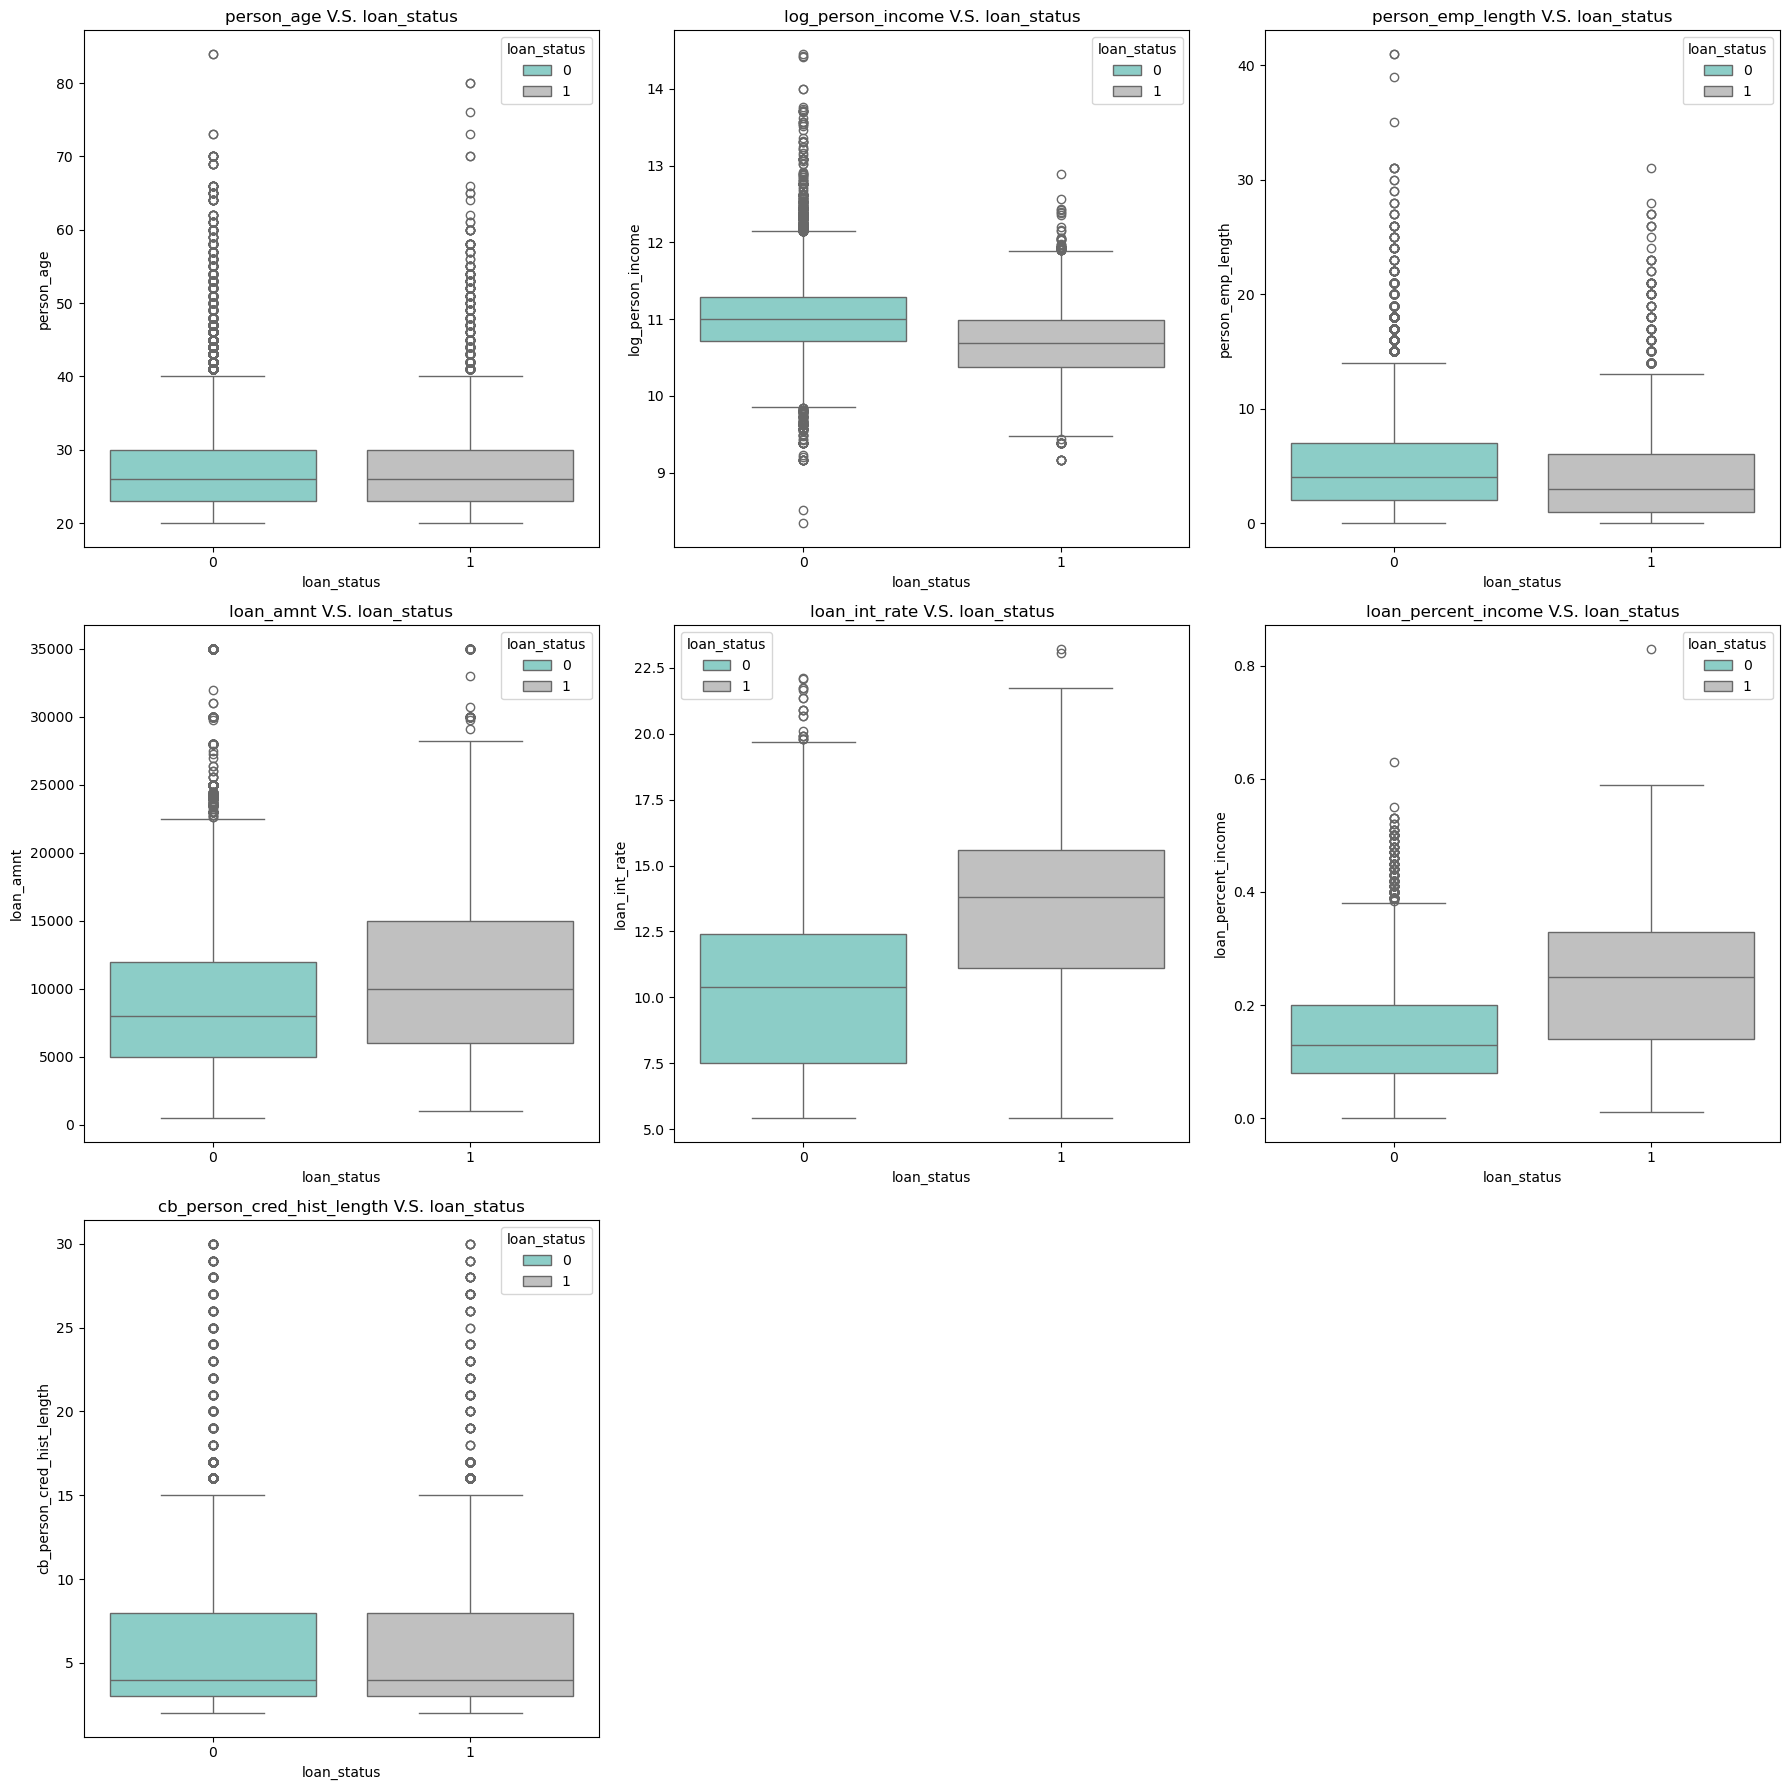

In [23]:
# numerical_cols V.S. loan_status

plt.figure(figsize = (18, 18))

# create multiple subplots (3 x 3)
for index, numerical_col in enumerate(numerical_cols):
    # plt.subplot(nrows, ncols, index), index start from 1
    plt.subplot(3, 3, index + 1)
    sns.boxplot(data = df, x = "loan_status", y = numerical_col, hue = "loan_status", palette = {0: "#81D8D0", 1: "silver"})
    plt.title(f"{numerical_col} V.S. loan_status")
    plt.xlabel("loan_status")
    plt.ylabel(numerical_col)

plt.tight_layout()
plt.show()

In [24]:
df["loan_int_group"], bins = pd.qcut(df["loan_int_rate"], q = 4, retbins = True)
loan_int_table = (df.groupby("loan_int_group", observed = True).agg(sample_size = ("loan_status", "count"), default_rate = ("loan_status", "mean")).reset_index())
loan_int_table["default_rate"] *= 100
loan_int_table

,loan_int_group,sample_size,default_rate
0,"(5.419, 7.88]",15988,4.265699
1,"(7.88, 10.75]",13715,8.151659
2,"(10.75, 12.99]",14581,11.768740
3,"(12.99, 23.22]",14358,33.660677


In [25]:
df["loan_int_group"] = pd.cut(df["loan_int_rate"], bins = [0, 8, 12, 16, 100], labels = ["<8%", "8%-12%", "12%-16%", ">16%"])
loan_int_table = (df.groupby("loan_int_group", observed = True).agg(sample_size = ("loan_status", "count"), default_rate = ("loan_status", "mean")).reset_index())
loan_int_table["default_rate"] *= 100
loan_int_table

,loan_int_group,sample_size,default_rate
0,<8%,17596,4.540805
1,8%-12%,21766,9.478085
2,12%-16%,17106,24.640477
3,>16%,2174,58.509660


=> Borrowers with defaulted loans tend to have higher interest rates than non-default borrowers, and previous default history is highly correlated with future default behavior.

In [27]:
df["loan_percent_group"] = pd.cut(df["loan_percent_income"], bins = [0, 0.1, 0.2, 0.3, 1], labels = ["<10%", "10%-20%", "20%-30%", ">30%"])
loan_percent_table = (df.groupby("loan_percent_group", observed = True).agg(sample_size = ("loan_status", "count"), default_rate = ("loan_status", "mean")).reset_index())
loan_percent_table["default_rate"] *= 100
loan_percent_table

,loan_percent_group,sample_size,default_rate
0,<10%,19402,6.679724
1,10%-20%,23766,9.185391
2,20%-30%,10743,14.670018
3,>30%,4729,69.655318


=> Borrowers with higher loan-to-income ratios exhibit higher default rates, suggesting loan burden is an important risk indicator.

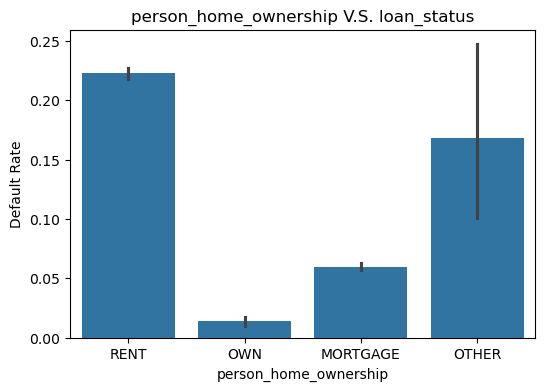

In [29]:
# person_home_ownership V.S. loan_status

plt.figure(figsize = (6, 4))
sns.barplot(data = df, x = "person_home_ownership", y = "loan_status")
plt.ylabel("Default Rate")
plt.title("person_home_ownership V.S. loan_status")
plt.show()

In [30]:
loan_ownership_table = (df.groupby("person_home_ownership").agg(sample_size = ("loan_status", "count"), default_rate = ("loan_status", "mean")).reset_index())
loan_ownership_table["default_rate"] *= 100
loan_ownership_table

,person_home_ownership,sample_size,default_rate
0,MORTGAGE,24821,5.970751
1,OTHER,89,16.853933
2,OWN,3138,1.370300
3,RENT,30594,22.255998


=> Home ownership status appears strongly associated with default risk. Borrowers who rent their homes have higher default rates than borrowers who own their homes or hold mortgages.

=> The OTHER category shows higher default rates. However, the sample size is very small.

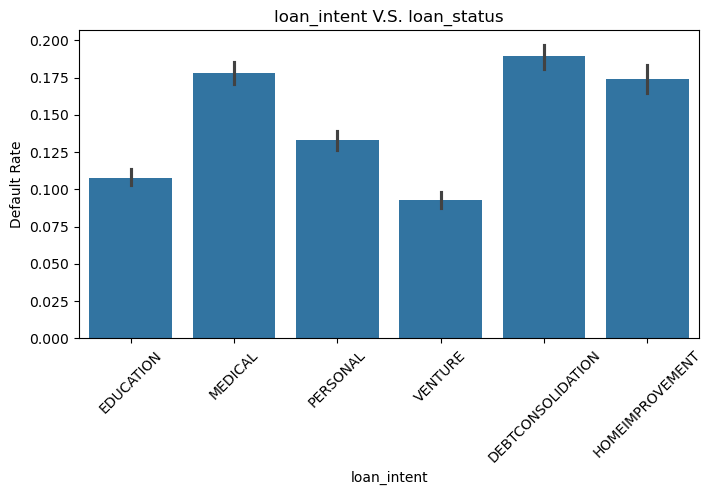

In [32]:
# loan_intent V.S. loan_status

plt.figure(figsize = (8, 4))
sns.barplot(data = df, x = "loan_intent", y = "loan_status")
plt.ylabel("Default Rate")
plt.xticks(rotation = 45)
plt.title("loan_intent V.S. loan_status")
plt.show()

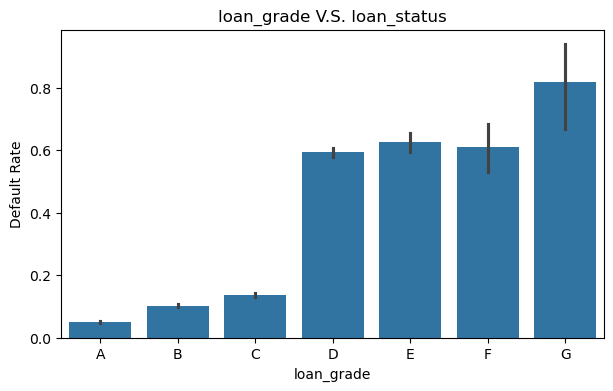

In [33]:
# loan_grade V.S. loan_status

plt.figure(figsize = (7, 4))
sns.barplot(data = df, x = "loan_grade", y = "loan_status", order = ["A", "B", "C", "D", "E", "F", "G"])
plt.ylabel("Default Rate")
plt.title("loan_grade V.S. loan_status")
plt.show()

In [34]:
loan_grade_table = (df.groupby("loan_grade").agg(sample_size = ("loan_status", "count"), default_rate = ("loan_status", "mean")).reset_index())
loan_grade_table["default_rate"] *= 100
loan_grade_table

,loan_grade,sample_size,default_rate
0,A,20984,4.918033
1,B,20398,10.231395
2,C,11036,13.537514
3,D,5033,59.348301
4,E,1009,62.537166
5,F,149,61.073826
6,G,33,81.818182


=> Default rates generally increase from Grade A to Grade G, while Grade E/F/G should be interpreted cautiously because sample sizes are small.

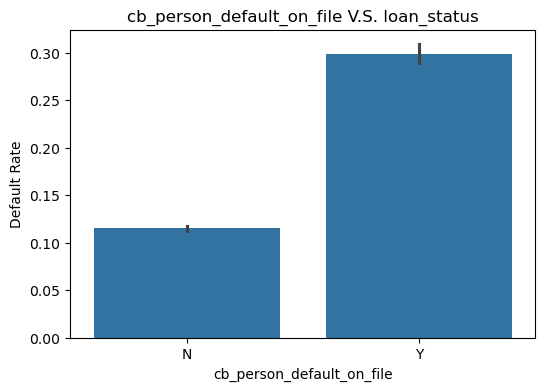

In [36]:
# cb_person_default_on_file V.S. loan_status

plt.figure(figsize = (6,4))
sns.barplot(data = df, x = "cb_person_default_on_file", y = "loan_status")
plt.ylabel("Default Rate")
plt.title("cb_person_default_on_file V.S. loan_status")
plt.show()

In [37]:
default_on_file_table = (df.groupby("cb_person_default_on_file").agg(sample_size = ("loan_status", "count"), default_rate = ("loan_status", "mean")).reset_index())
default_on_file_table["default_rate"] *= 100
default_on_file_table

,cb_person_default_on_file,sample_size,default_rate
0,N,49941,11.511584
1,Y,8701,29.881623


=> Historical default (cb_person_default_on_file) predicts future risk well, but its impact may already be captured by loan_grade.

### 5. Correlation Matrix

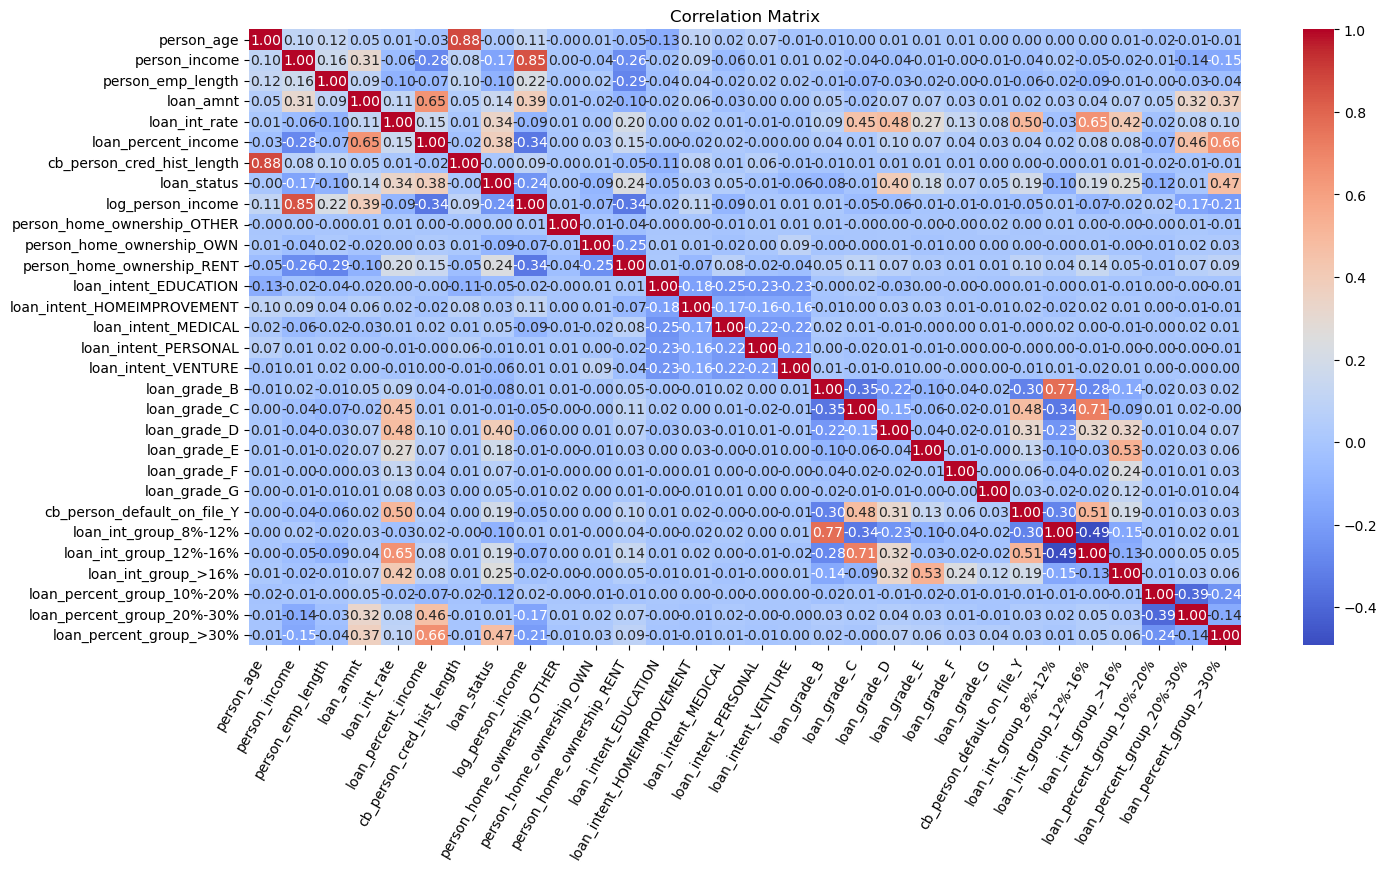

In [40]:
# one-hot encoding

df_encoded = pd.get_dummies(df, drop_first = True)

# heatmap

plt.figure(figsize = (16,8))
sns.heatmap(df_encoded.corr(), annot = True, cmap = "coolwarm", fmt = ".2f")
plt.xticks(rotation = 60, ha = "right")
plt.title("Correlation Matrix")
plt.show()

### 6. Additional Feature Relationships

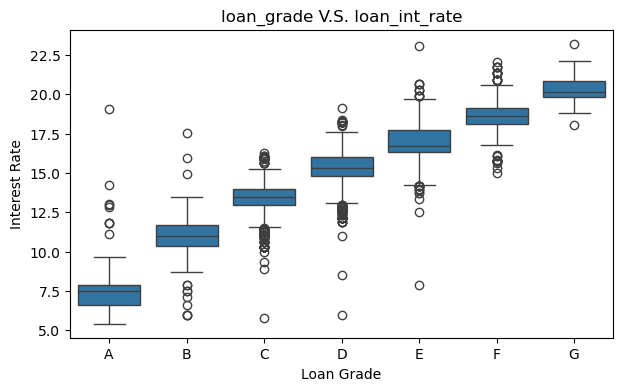

In [42]:
# loan_grade V.S. loan_int_rate

plt.figure(figsize = (7, 4))
sns.boxplot(data = df, x = "loan_grade", y = "loan_int_rate", order = ["A","B","C","D","E","F","G"])
plt.ylabel("Interest Rate")
plt.xlabel("Loan Grade")
plt.title("loan_grade V.S. loan_int_rate")
plt.show()

=> Borrowers with worse loan grades generally receive higher interest rates.

=> This supports the multicollinearity observed between loan_grade and loan_int_rate.

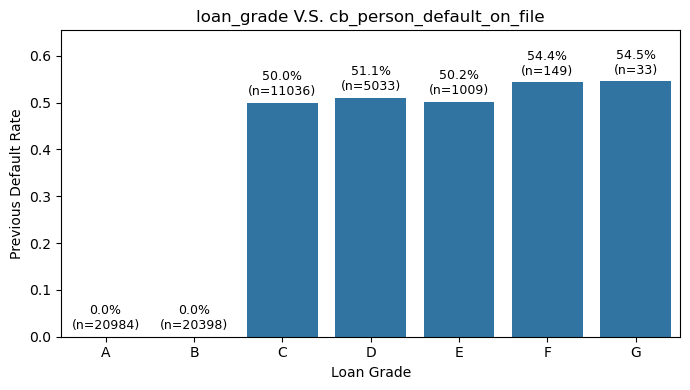

,loan_grade,sample_size,previous_default_rate
0,A,20984,0.000191
1,B,20398,0.000294
2,C,11036,0.499547
3,D,5033,0.511027
4,E,1009,0.502478
5,F,149,0.543624
6,G,33,0.545455


In [44]:
# loan_grade V.S. cb_person_default_on_file

default_grade = (df.groupby("loan_grade").agg(sample_size = ("loan_grade", "count"), previous_default_rate = ("cb_person_default_on_file", lambda x: (x == "Y").mean())).reset_index())

plt.figure(figsize = (7, 4))

ax = sns.barplot(data = default_grade, x = "loan_grade", y = "previous_default_rate", order = ["A", "B", "C", "D", "E", "F", "G"])

for i, row in default_grade.iterrows():
    ax.text(i,
            row["previous_default_rate"] + 0.01,
            f'{row["previous_default_rate"]*100:.1f}%\n(n={row["sample_size"]})',
            ha = "center",
            va = "bottom",
            fontsize = 9)

plt.ylabel("Previous Default Rate")
plt.xlabel("Loan Grade")
plt.title("loan_grade V.S. cb_person_default_on_file")
plt.margins(y = 0.2)
plt.tight_layout()
plt.show()

default_grade

=> Borrowers with poorer loan grades are more likely to have previous defaults. Previous default history increases substantially as loan grade deteriorates, suggesting that loan grade already captures part of the information contained in historical default records.

=> This suggests that loan_grade already incorporates information related to historical default behavior.

In [46]:
'''
Removed:
- person_age > 100
- person_emp_length > 100

Log Transformation:
- log_person_income
'''

'\nRemoved:\n- person_age > 100\n- person_emp_length > 100\n\nLog Transformation:\n- log_person_income\n'

### Notes:

> No missing values or duplicates.
> 
> The dataset is imbalanced, with approximately 14.24% default loans and 85.76% non-default loans.
> 
> A few extreme values exist. Records with extremely high age and tenure (person_age, person_emp_length) are removed. Extremely high personal income (person_income) may represent genuine high earners rather than data errors.
> 
> Higher loan burden (loan_percent_income) and higher interest rate (loan_int_rate) are associated with higher default risk.
> 
> Loan grade (loan_grade) and previous default history (cb_person_default_on_file) are strong predictors of future default behavior.
>
> Home ownership status is strongly associated with default risk. Borrowers who rent their homes tend to have higher default rates than borrowers who own their homes or hold mortgages.